In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_ml = pd.read_csv(r"D:\Div\turboaz_data_cleaning\turboaz_cars_cleaned.csv")

In [3]:
df_ml. info()

<class 'pandas.DataFrame'>
RangeIndex: 234780 entries, 0 to 234779
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   city                     234780 non-null  str    
 1   day                      234780 non-null  str    
 2   hour                     234780 non-null  int64  
 3   engine_displacement_num  234780 non-null  float64
 4   kilometrage_num          234780 non-null  int64  
 5   barter                   234780 non-null  int64  
 6   loan                     234780 non-null  int64  
 7   salon                    234780 non-null  int64  
 8   vip                      234780 non-null  int64  
 9   featured                 234780 non-null  int64  
 10  price                    234780 non-null  float64
 11  currency                 234780 non-null  str    
 12  shop_name                234780 non-null  str    
 13  views                    234780 non-null  int64  
 14  ban_type       

In [4]:
df_ml.describe()

,hour,engine_displacement_num,kilometrage_num,barter,loan,salon,vip,featured,price,views,production_year,Vəziyyəti,Yeni,seat_count,at_gucu,Kondisioner,Arxa_kamera,Rənglənib,price_azn
count,234780.000000,234780.000000,2.347800e+05,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000,234780.000000
mean,15.250106,2.166996,1.974093e+05,0.268941,0.179913,0.141592,0.240267,0.125973,24058.161969,1282.979014,2010.956998,0.016156,0.051968,5.049387,178.162791,0.888440,0.675351,0.079104,29534.051096
std,4.692447,1.175405,1.588193e+05,0.443410,0.384116,0.348632,0.427247,0.331820,20929.528435,4308.416457,8.207067,0.126074,0.221963,0.851568,95.315636,0.314825,0.468244,0.269901,34970.654319
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,14.000000,1938.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,500.000000
25%,12.000000,1.600000,9.806325e+04,0.000000,0.000000,0.000000,0.000000,0.000000,12000.000000,181.000000,2007.000000,0.000000,0.000000,5.000000,115.000000,1.000000,0.000000,0.000000,12000.000000
50%,15.000000,2.000000,1.824000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,20500.000000,358.000000,2012.000000,0.000000,0.000000,5.000000,160.000000,1.000000,1.000000,0.000000,21000.000000
75%,19.000000,2.400000,2.667225e+05,1.000000,0.000000,0.000000,0.000000,0.000000,29800.000000,1034.000000,2016.000000,0.000000,0.000000,5.000000,204.000000,1.000000,1.000000,0.000000,34000.000000
max,23.000000,120.000000,9.900025e+06,1.000000,1.000000,1.000000,1.000000,1.000000,940000.000000,343154.000000,2024.000000,1.000000,1.000000,8.000000,2000.000000,1.000000,1.000000,1.000000,940000.000000


In [5]:
df_ml.columns

Index(['city', 'day', 'hour', 'engine_displacement_num', 'kilometrage_num',
       'barter', 'loan', 'salon', 'vip', 'featured', 'price', 'currency',
       'shop_name', 'views', 'ban_type', 'production_year', 'market_type',
       'Marka', 'Model', 'Qəzalı', 'Rəng', 'Sahiblər', 'transmission',
       'Vəziyyəti', 'Yeni', 'seat_count', 'drivetrain', 'at_gucu',
       'yanacaq_novu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib', 'price_azn'],
      dtype='str')

In [6]:
df_ml.select_dtypes(include=['int','float']).corr()['price_azn'].sort_values(ascending=False)

price_azn                  1.000000
price                      0.961990
at_gucu                    0.624790
production_year            0.460567
salon                      0.328688
Arxa_kamera                0.304952
Yeni                       0.271081
engine_displacement_num    0.254294
Kondisioner                0.203249
vip                        0.181130
featured                   0.180776
barter                     0.152182
seat_count                 0.129122
views                      0.083409
loan                       0.042848
hour                      -0.046333
Vəziyyəti                 -0.048904
Rənglənib                 -0.100315
kilometrage_num           -0.292402
Name: price_azn, dtype: float64

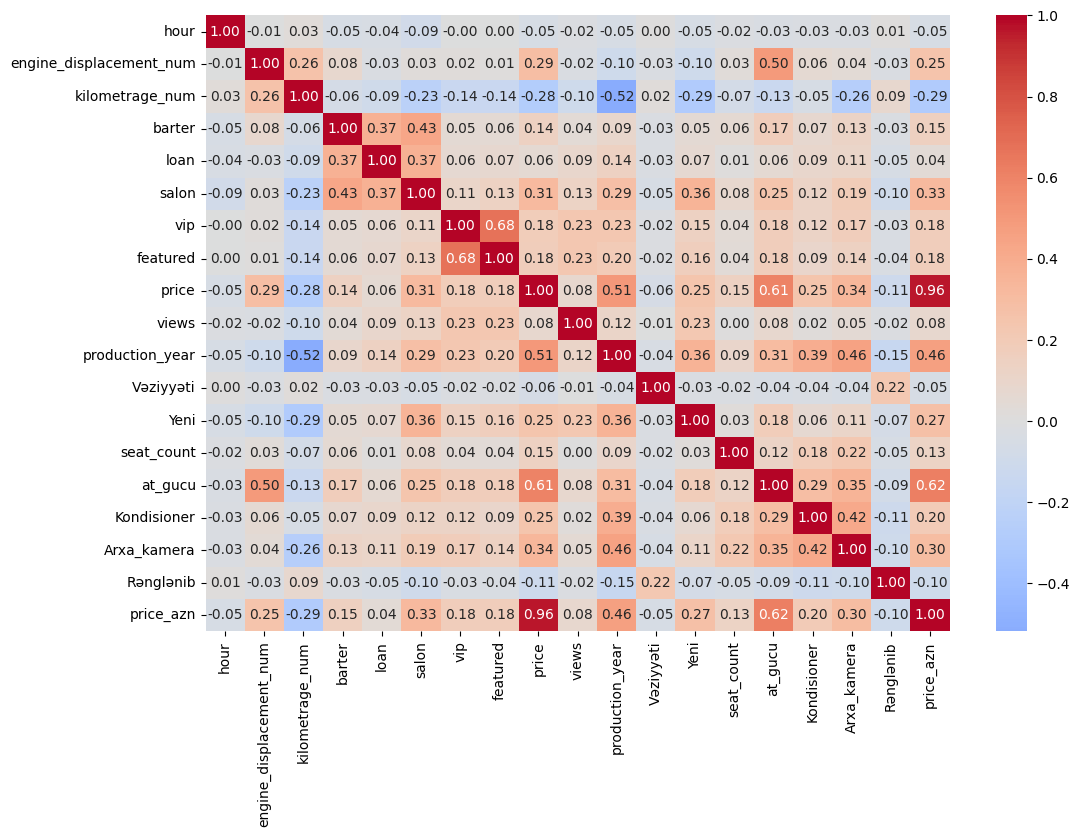

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_ml.select_dtypes(include=['int','float']).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

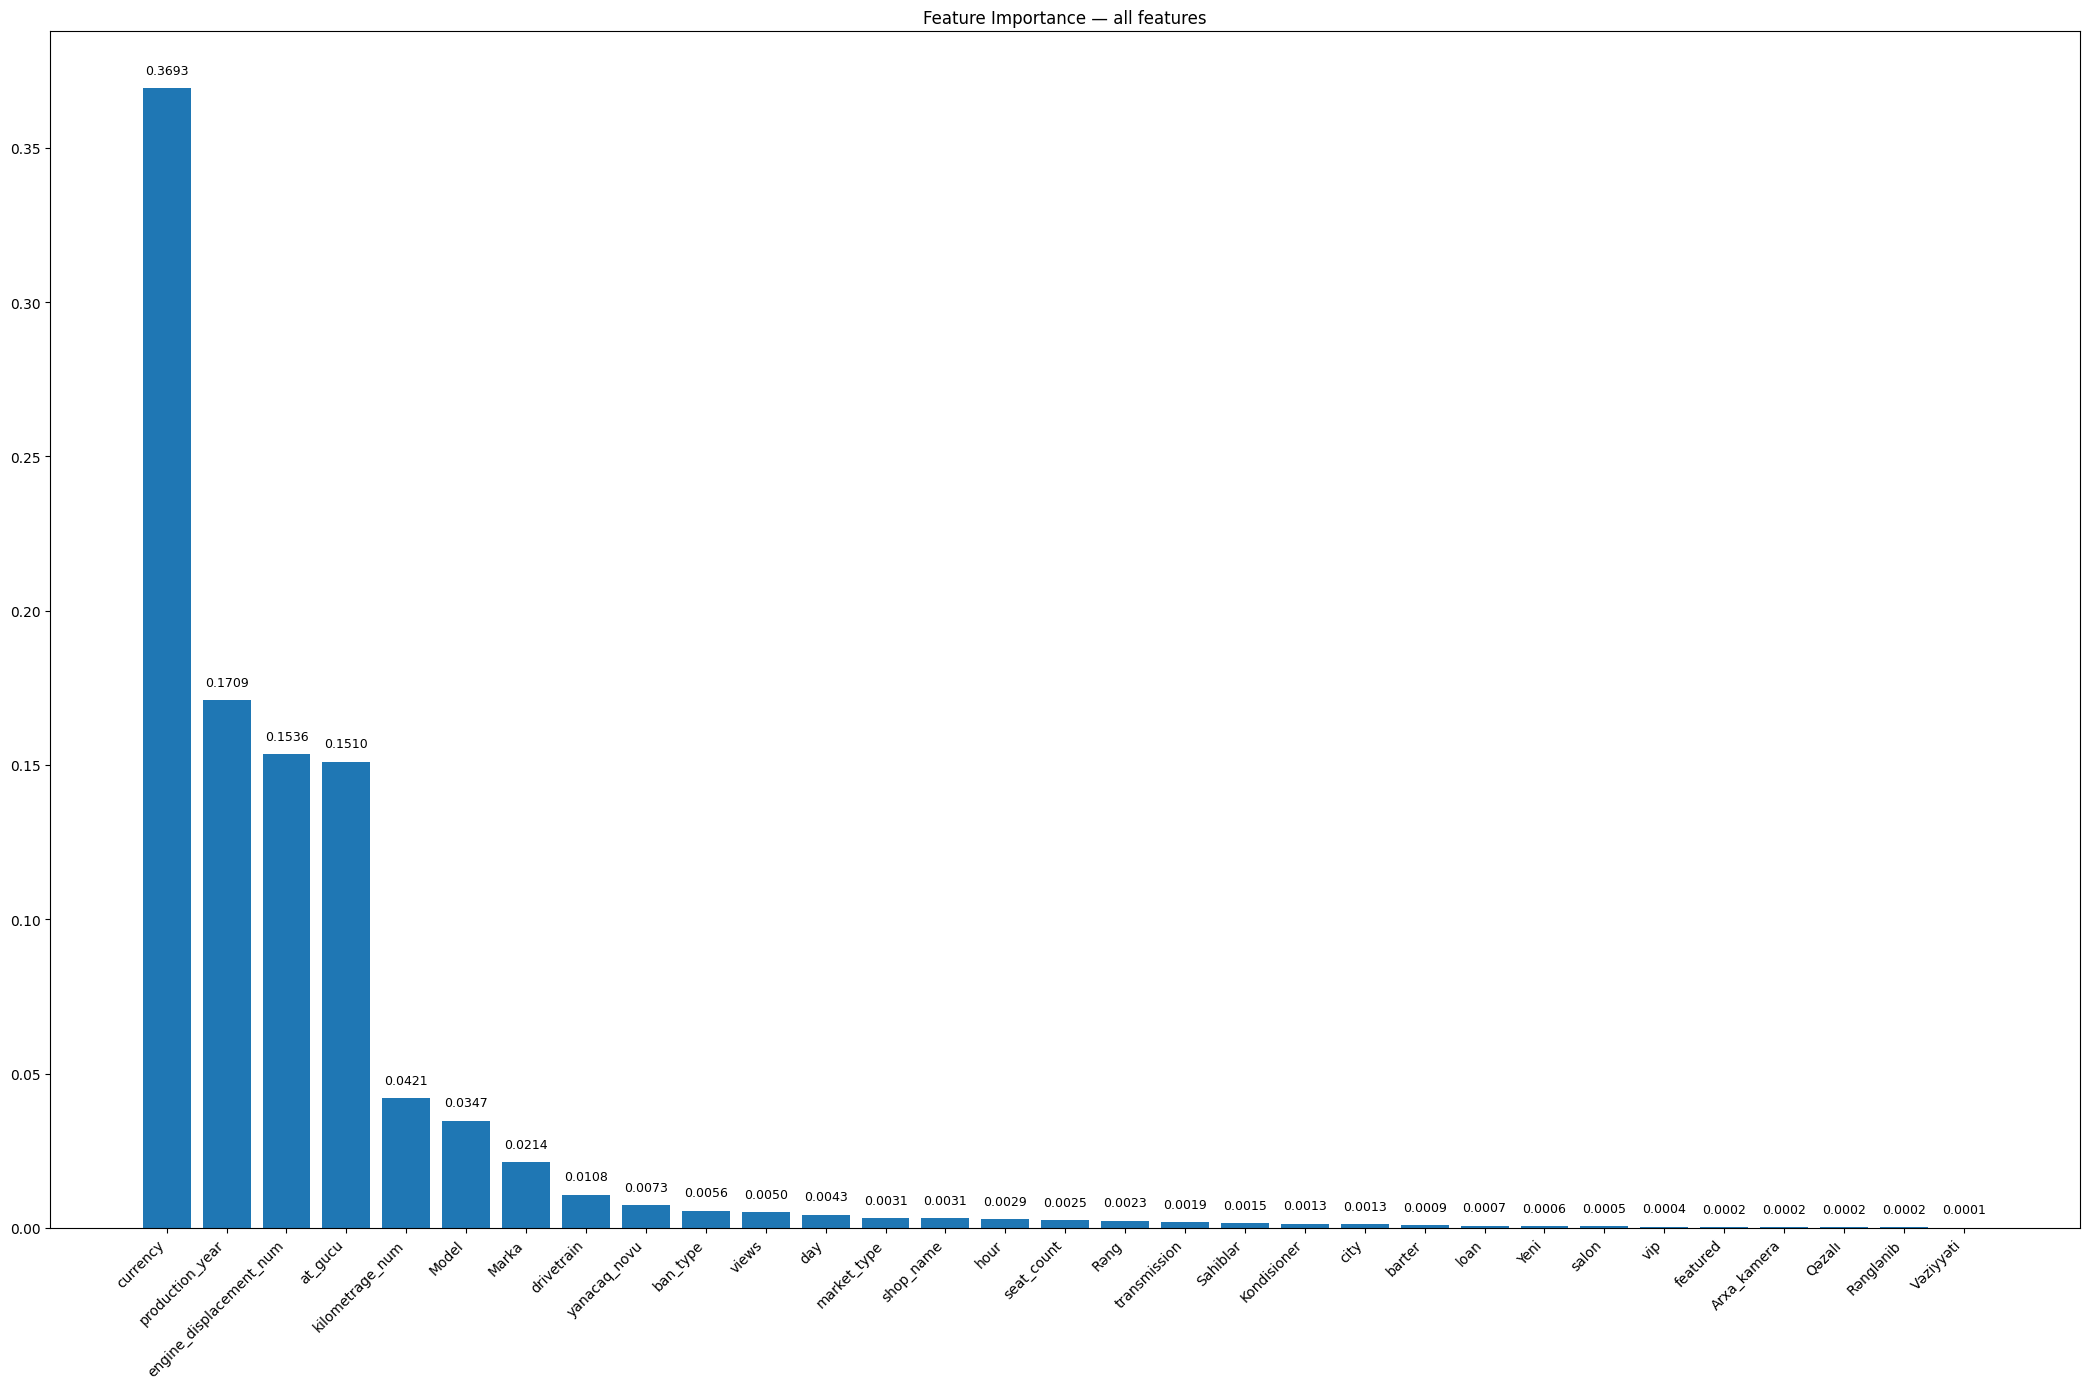

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_enc = df_ml.copy()

text_cols = df_enc.select_dtypes(include='string').columns

for col in text_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

X = df_enc.drop(columns=['price_azn', 'price'])
y = df_enc['price_azn']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(21, 14))

bars = plt.bar(importance.index, importance.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,  
        height + (importance.max() * 0.01),   
        f'{height:.4f}',                      
        ha='center',                           
        va='bottom',                         
        fontsize=9                            
    )

plt.title('Feature Importance — all features')
plt.xticks(rotation=45, ha='right')           
plt.tight_layout()
plt.show();


In [8]:
df_ml.drop(columns= ['price','currency','day','hour','views'], inplace = True)

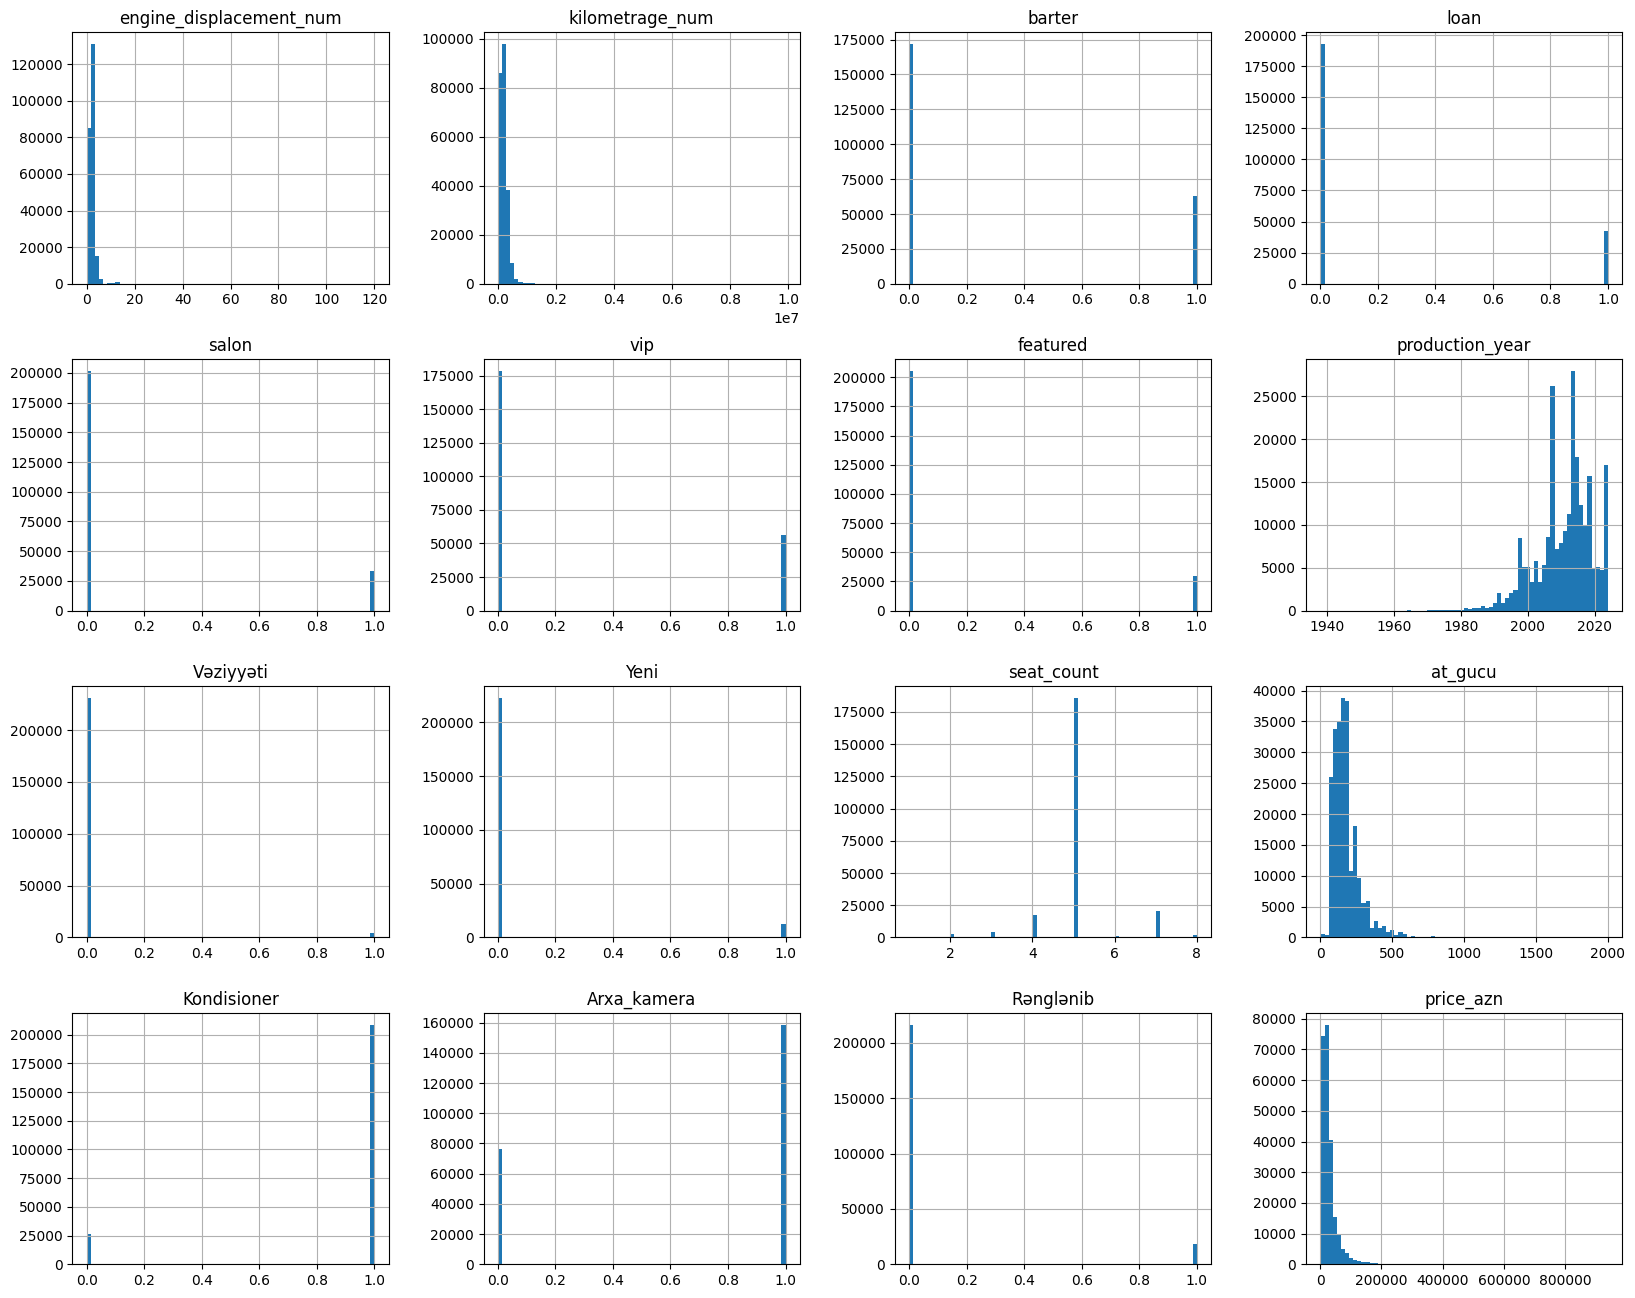

In [9]:
df_ml.hist(figsize=(20,16), bins=70)
plt.show();

In [9]:
df_ml.columns

Index(['city', 'engine_displacement_num', 'kilometrage_num', 'barter', 'loan',
       'salon', 'vip', 'featured', 'shop_name', 'ban_type', 'production_year',
       'market_type', 'Marka', 'Model', 'Qəzalı', 'Rəng', 'Sahiblər',
       'transmission', 'Vəziyyəti', 'Yeni', 'seat_count', 'drivetrain',
       'at_gucu', 'yanacaq_novu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib',
       'price_azn'],
      dtype='str')

In [10]:
cols_for_outliers=['kilometrage_num',
    'engine_displacement_num',
    'at_gucu',
    'production_year']

In [11]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(contamination=0.01, random_state=42)
iso_f.fit(df_ml.loc[:, cols_for_outliers])
outlier_pred = iso_f.predict(df_ml.loc[:, cols_for_outliers])
outlier_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(234780,))

In [12]:
df_ml.shape

(234780, 28)

In [13]:
outlier_mask = (outlier_pred == -1)
df_ml.loc[~outlier_mask, :]

,city,engine_displacement_num,kilometrage_num,barter,loan,salon,vip,featured,shop_name,ban_type,...,Vəziyyəti,Yeni,seat_count,drivetrain,at_gucu,yanacaq_novu,Kondisioner,Arxa_kamera,Rənglənib,price_azn
0,bakı,1.6,270000,0,0,0,0,0,Fiziki şəxs,Hetçbek,...,0,0,5,Ön,115.0,Dizel,1,0,0,15000.0
1,bakı,1.7,0,0,0,1,1,1,Lada Azərbaycan,Offroader / SUV,...,0,1,5,Tam,80.0,Benzin,1,0,0,23700.0
2,bakı,4.0,164750,0,0,0,1,1,Fiziki şəxs,Offroader / SUV,...,0,0,8,Tam,282.0,Benzin,1,1,0,60520.0
3,bakı,2.0,126000,0,0,0,1,0,Fiziki şəxs,Sedan,...,0,0,5,Ön,150.0,Benzin,1,1,0,26700.0
4,bakı,1.5,354000,0,0,0,1,0,Fiziki şəxs,Liftbek,...,0,0,5,Ön,76.0,Hibrid,0,1,0,10500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234775,bakı,1.6,63000,0,0,0,0,0,Fiziki şəxs,Sedan,...,0,0,4,Arxa,75.0,Benzin,0,1,0,7750.0
234776,bakı,1.5,320000,1,0,0,0,0,Fiziki şəxs,Liftbek,...,0,0,5,Ön,76.0,Hibrid,1,1,0,10800.0
234777,göygöl,2.9,155000,0,0,0,0,0,Fiziki şəxs,Offroader / SUV,...,0,0,5,Tam,135.0,Benzin,0,0,0,9500.0
234778,kürdəmir,4.7,250000,1,0,0,0,0,Fiziki şəxs,Offroader / SUV,...,0,0,5,Tam,258.0,Benzin,1,0,0,10600.0


In [14]:
df_ml = df_ml.loc[outlier_pred == 1].reset_index(drop=True)

In [15]:
X = df_ml.drop(columns='price_azn')
y = df_ml['price_azn']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	X, 
	y, 
	test_size=0.2
)

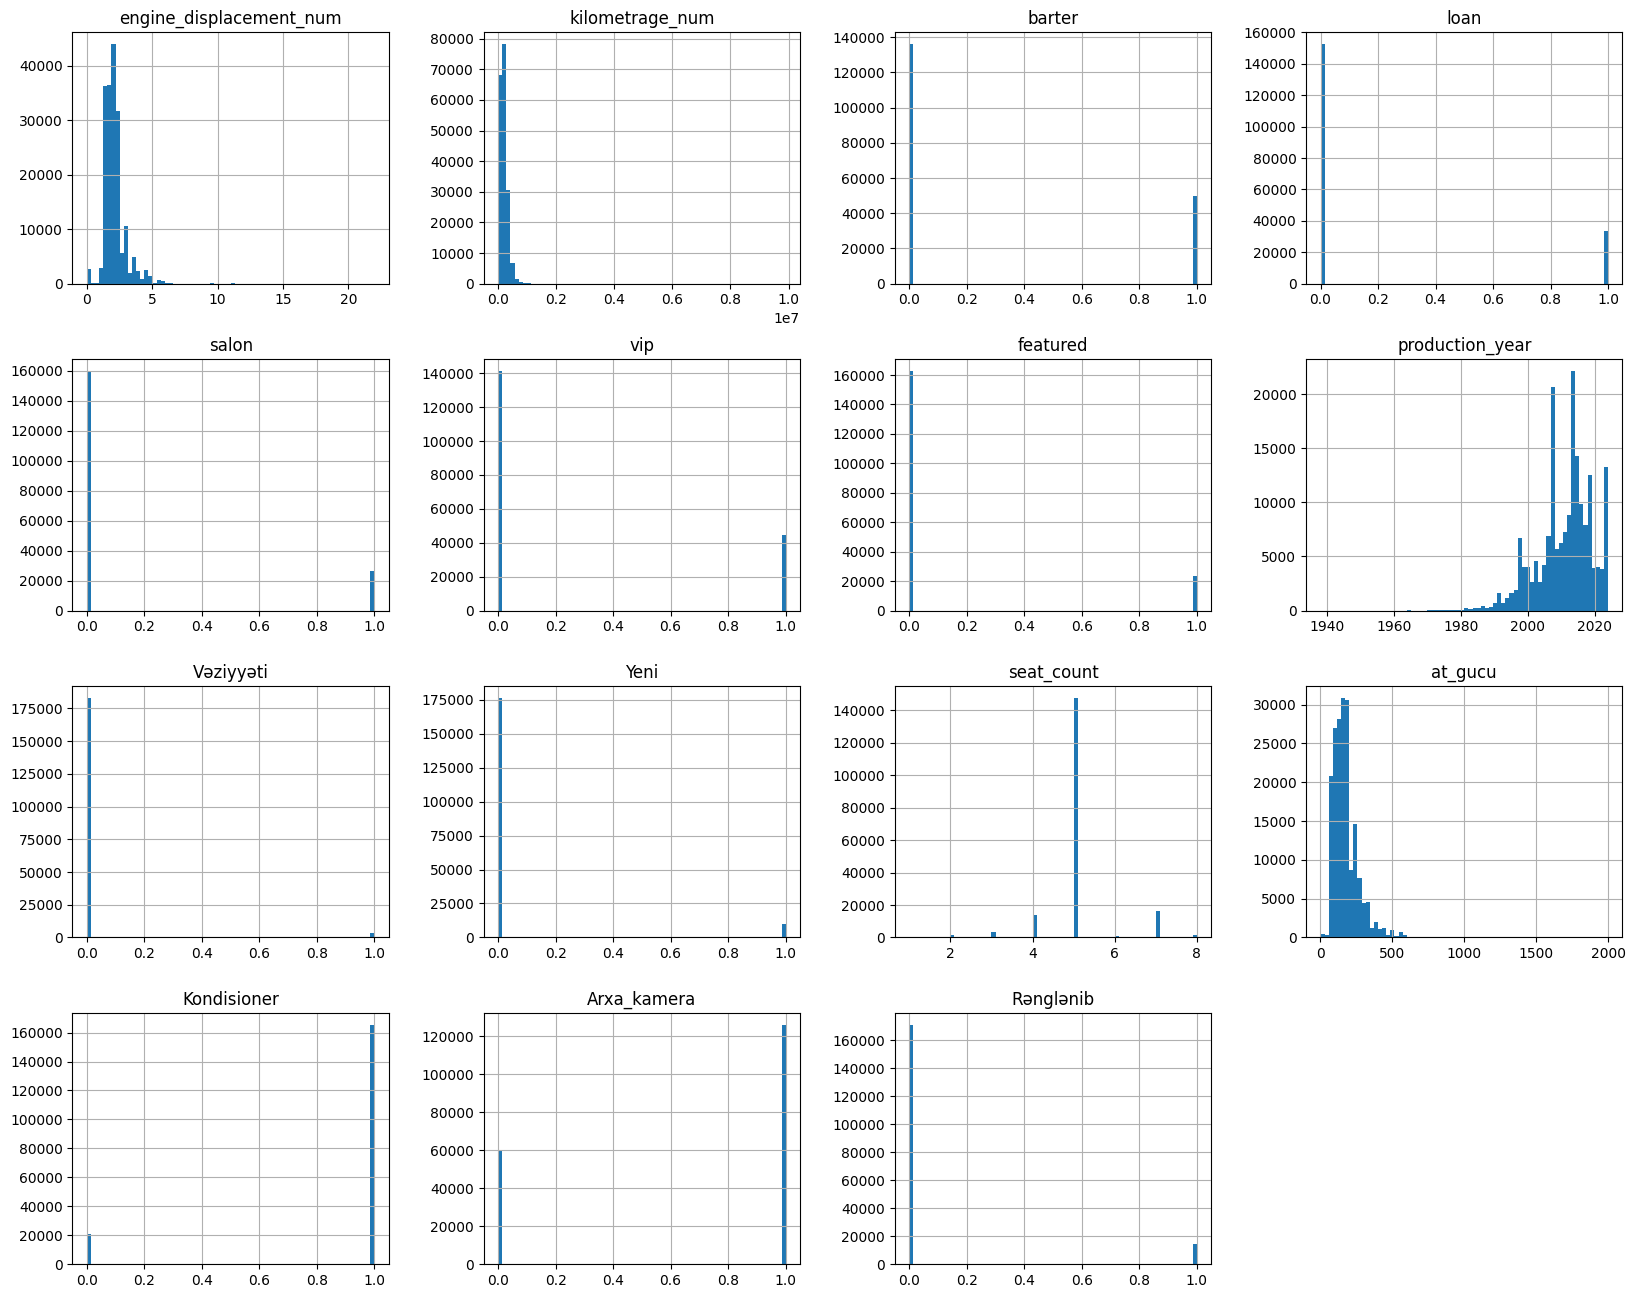

In [21]:
X_train.hist(figsize=(20,16),bins=70);

In [17]:
X_train.select_dtypes(include=['int','float']).columns

Index(['engine_displacement_num', 'kilometrage_num', 'barter', 'loan', 'salon',
       'vip', 'featured', 'production_year', 'Vəziyyəti', 'Yeni', 'seat_count',
       'at_gucu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib'],
      dtype='str')

In [18]:
cat_cols = X_train.select_dtypes(include=['str','category']).columns

In [19]:
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()}")

city: 74
shop_name: 315
ban_type: 29
market_type: 9
Marka: 200
Model: 2234
Qəzalı: 2
Rəng: 18
Sahiblər: 6
transmission: 5
drivetrain: 3
yanacaq_novu: 7


In [20]:
X_train.columns

Index(['city', 'engine_displacement_num', 'kilometrage_num', 'barter', 'loan',
       'salon', 'vip', 'featured', 'shop_name', 'ban_type', 'production_year',
       'market_type', 'Marka', 'Model', 'Qəzalı', 'Rəng', 'Sahiblər',
       'transmission', 'Vəziyyəti', 'Yeni', 'seat_count', 'drivetrain',
       'at_gucu', 'yanacaq_novu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib'],
      dtype='str')

In [21]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols =['engine_displacement_num','production_year','seat_count', 'at_gucu']
log_cols =['kilometrage_num']
onehot_cols = ['market_type','Qəzalı','Sahiblər','transmission','drivetrain','yanacaq_novu']
target_cols = ['city','shop_name','Marka','Model','Rəng','ban_type']
binary_cols =['barter', 'loan', 'salon','vip', 'featured', 'Vəziyyəti', 'Yeni', 'Kondisioner', 'Arxa_kamera', 'Rənglənib']

num_pipeline = Pipeline([
	('scl', StandardScaler())
])
log_pipeline = Pipeline([
	('log', FunctionTransformer(func=np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')),
	('scl', StandardScaler())
])
onehot_pipeline = Pipeline([
	('enc', OneHotEncoder(sparse_output=False)),
])
target_pipeline = Pipeline([
	('tenc', TargetEncoder()),
])

col_trans = ColumnTransformer([
	('NUM', num_pipeline, num_cols),
	('LOG', log_pipeline, log_cols),
	('ENC', onehot_pipeline, onehot_cols),
    ('TENC', target_pipeline, target_cols),
],remainder='passthrough')

X_train_arr = col_trans.fit_transform(X_train,y_train)
X_train_prepared = pd.DataFrame(X_train_arr, columns=col_trans.get_feature_names_out())

X_test_arr = col_trans.transform(X_test)
X_test_prepared = pd.DataFrame(X_test_arr, columns=col_trans.get_feature_names_out())

X_train_prepared

,NUM__engine_displacement_num,NUM__production_year,NUM__seat_count,NUM__at_gucu,LOG__kilometrage_num,ENC__market_type_Amerika,ENC__market_type_Avropa,ENC__market_type_Digər,ENC__market_type_Dubay,ENC__market_type_Koreya,...,remainder__barter,remainder__loan,remainder__salon,remainder__vip,remainder__featured,remainder__Vəziyyəti,remainder__Yeni,remainder__Kondisioner,remainder__Arxa_kamera,remainder__Rənglənib
0,0.697182,-0.361454,-0.072689,0.244268,0.449756,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.462585,-1.095542,-0.072689,0.188200,0.554283,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-0.475800,0.494983,-0.072689,-0.383694,0.252529,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
3,-0.593098,-1.462587,-0.072689,-1.123793,0.583450,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.123905,0.617331,-0.072689,0.098491,0.299165,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185940,0.579884,-1.217890,-0.072689,-0.058500,0.604846,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
185941,-0.123905,1.106724,-0.072689,-0.293986,0.008472,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
185942,0.110691,-1.340239,-0.072689,-0.282772,0.520795,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
185943,-0.123905,1.596116,-0.072689,3.215875,-4.026096,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


In [ ]:
# from sklearn.linear_model import LinearRegression

# lin_reg = Pipeline([
#     ("cleaning", col_trans), 
#     ("linreg", LinearRegression())
#     ])
# lin_reg.fit(X_train, y_train)
# y_pred = lin_reg.predict(X_test)

In [ ]:
# (np.sqrt((y_test.to_numpy()-y_pred)**2)).mean() #MAE

np.float64(7664.187238050756)

In [ ]:
# np.sqrt(((y_test.to_numpy() - y_pred) ** 2).mean()) #RMSE

np.float64(15657.512336046047)

In [ ]:
# from sklearn.metrics import (
#     mean_absolute_error,
#     root_mean_squared_error,
#     r2_score
# )

# mae = mean_absolute_error(y_test, y_pred)
# rmse = root_mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"MAE : {mae:.2f}")
# print(f"RMSE: {rmse:.2f}")
# print(f"R²  : {r2:.4f}")

MAE : 7664.19
RMSE: 15657.51
R²  : 0.7642


In [ ]:
# from sklearn.linear_model import Ridge

# ridge_reg = Pipeline([
#     ("cleaning", col_trans),
#     ("ridge", Ridge(alpha=1.0))
# ])

# ridge_reg.fit(X_train, y_train)
# y_pred = ridge_reg.predict(X_test)

# ridge_mae = mean_absolute_error(y_test, y_pred)
# ridge_rmse = root_mean_squared_error(y_test, y_pred)
# ridge_r2 = r2_score(y_test, y_pred)

# ridge_mae, ridge_rmse, ridge_r2

(7678.956453707433, 15662.448375281396, 0.7640347416027511)

In [ ]:
# from sklearn.linear_model import Lasso

# lasso_reg = Pipeline([
#     ("cleaning", col_trans),
#     ("lasso", Lasso(alpha=0.1))
# ])

# lasso_reg.fit(X_train, y_train)
# y_pred = lasso_reg.predict(X_test)

# lasso_mae = mean_absolute_error(y_test, y_pred)
# lasso_rmse = root_mean_squared_error(y_test, y_pred)
# lasso_r2 = r2_score(y_test, y_pred)

# lasso_mae, lasso_rmse, lasso_r2

c:\Users\User\miniconda3\envs\ds\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.045e+13, tolerance: 2.035e+10
  model = cd_fast.enet_coordinate_descent(


(7660.371434744012, 15657.314341041396, 0.7641894115667662)

In [ ]:
# from sklearn.tree import DecisionTreeRegressor

# tree_reg = Pipeline([
#     ("cleaning", col_trans), 
#     ("treereg", DecisionTreeRegressor(random_state = 42))
#     ])
# tree_reg.fit(X_train, y_train)
# y_pred = tree_reg.predict(X_test)
# tree_mae = mean_absolute_error(y_test, y_pred)
# tree_rmse = root_mean_squared_error(y_test, y_pred)
# tree_r2 = r2_score(y_test, y_pred)
# tree_mae, tree_rmse, tree_r2

(2848.471208294792, 10009.935084714807, 0.903619032240634)

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor

forest_reg = Pipeline([
    ("cleaning", col_trans), 
    ("forestreg", RandomForestRegressor(random_state = 42))
    ])
forest_reg.fit(X_train, y_train)
y_pred = forest_reg.predict(X_test)
forest_mae = mean_absolute_error(y_test, y_pred)
forest_rmse = root_mean_squared_error(y_test, y_pred)
forest_r2 = r2_score(y_test, y_pred)
forest_mae,forest_rmse,forest_r2

(2191.9323371515607, 7207.858639589518, 0.9534917159121981)

In [ ]:
# from sklearn.ensemble import RandomForestRegressor

# forest_reg = Pipeline([
#     ("cleaning", col_trans), 
#     ("forestreg", RandomForestRegressor(random_state=42,
#     n_estimators=200,
#     max_depth=20,
#     min_samples_leaf=2))
#     ])
# forest_reg.fit(X_train, y_train)
# y_pred = forest_reg.predict(X_test)
# forest_rmse = root_mean_squared_error(y_test, y_pred)
# forest_rmse

6081.517466198692

In [ ]:
# forest_rmse = root_mean_squared_error(y_test, y_pred)
# forest_r2 = r2_score(y_test, y_pred)
# forest_mae,forest_rmse,forest_r2

(2201.0616071528557, 6081.517466198692, 0.9644243636312402)

In [23]:
from pathlib import Path

In [24]:
import joblib 
model_dir = Path(r"D:\Div\turboaz_project")
model_path = model_dir/ 'model.pk'
joblib.dump(forest_reg,model_path)

['D:\\Div\\turboaz_project\\model.pk']

In [25]:
import joblib 
model_dir = Path(r"D:\Div\turboaz_project")
model_path = model_dir/ 'model.pk'
new_forest_reg = joblib.load(model_path)
new_forest_reg.predict(X_test.iloc[[1],:])

array([7533.48])